# UT8 - Reduccion de Dimensionalidad
**Alumno:** autor  
**DNI:** XXXXXXXXX  
**Fecha:** Marzo 2026

---

## Dataset: Heart Disease (Cleveland) - UCI

Para este trabajo he elegido el dataset **Heart Disease** del repositorio UCI (https://archive.ics.uci.edu/dataset/45/heart+disease). Son datos clinicos de 303 pacientes del Cleveland Clinic y el objetivo es predecir si el paciente tiene enfermedad cardiaca o no.

Tiene 13 features de entrada, unas cuantas numericas (edad, presion arterial, colesterol, frecuencia cardiaca maxima...) y otras que son categoricas aunque esten codificadas con numeros (tipo de dolor toracico, resultado del ECG, talasemia...). La variable objetivo es binaria: 0 = sano, 1 = enfermo.

He elegido este dataset porque tiene suficientes variables para que tenga sentido aplicar PCA y tecnicas de seleccion de features, mezcla variables numericas y categoricas, y tiene algunos valores nulos para practicar el preprocesado.

**Enlace al video:** https://www.youtube.com/watch?v=kEiox28jbu4

---

## Indice

1. [Preprocesado de los datos](#1)
2. [Modelo de clasificacion base](#2)
3. [Correlation Analysis](#3)
4. [Feature Importances](#4)
5. [Univariate Selection - ANOVA](#5)
6. [Recursive Feature Elimination](#6)
7. [Modelo con dataset reducido](#7)
8. [PCA - Reduccion de dimensionalidad](#8)
9. [Modelo con PCA](#9)
10. [Conclusiones](#10)

<a name="1"></a>
# 1. Preprocesado de los datos

En esta seccion preparamos los datos para que los algoritmos de machine learning puedan trabajar con ellos correctamente. Esto es necesario porque los datos en crudo suelen tener problemas: valores que faltan, variables categoricas que no se pueden meter directamente en un modelo numerico, y escalas muy diferentes entre variables que pueden sesgar los resultados (sobre todo en PCA). Seguimos el flujo habitual: cargar, explorar, limpiar nulos, codificar categoricas, separar train/test y estandarizar.

## 1.1 Importar librerias

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OrdinalEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_curve, auc
from sklearn.feature_selection import SelectKBest, f_classif, RFE
from sklearn.decomposition import PCA

## 1.2 Importar dataset

Cargamos el dataset directamente desde la URL de UCI, de forma similar a como se hizo con el Iris en el Colab de clase. Los valores faltantes en este dataset vienen como '?' asi que indicamos a pandas que los trate como NaN.

In [2]:
# Cargar dataset desde UCI
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data'
names = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
         'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

dataset = pd.read_csv(url, names=names, na_values='?')
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB


In [3]:
dataset.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [4]:
dataset.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000


Veamos como esta repartida la variable target. En los datos originales tiene valores de 0 a 4 (grados de enfermedad), pero como el objetivo es clasificacion binaria, lo convertimos en: 0 = sano, 1 = enfermo.

Target original:
target
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64

Target binarizado:
target
0    164
1    139
Name: count, dtype: int64


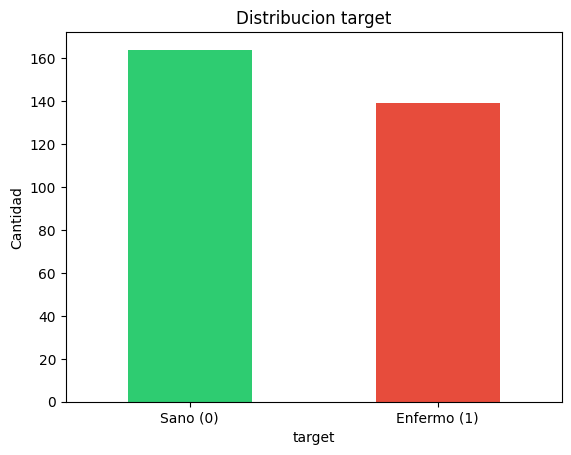

In [5]:
print('Target original:')
print(dataset['target'].value_counts())

# Binarizar: 0 = sano, cualquier otro valor = enfermo
dataset['target'] = (dataset['target'] > 0).astype(int)

print('\nTarget binarizado:')
print(dataset['target'].value_counts())

# Grafico rapido
dataset['target'].value_counts().plot(kind='bar', color=['#2ecc71', '#e74c3c'])
plt.title('Distribucion target')
plt.xticks([0, 1], ['Sano (0)', 'Enfermo (1)'], rotation=0)
plt.ylabel('Cantidad')
plt.show()

## 1.3 Manejo de datos missing

Comprobamos si hay nulos. En el Colab de clase con Iris no habia nulos, pero aqui si que hay algunos.

In [6]:
# Comprobar nulos
print(dataset.isnull().sum())
print(f'\nTotal nulos: {dataset.isnull().sum().sum()} de {dataset.size} valores')

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

Total nulos: 6 de 4242 valores


Solo hay 6 nulos entre `ca` (4) y `thal` (2). Son muy pocos comparado con las 303 filas, asi que se eliminan directamente. Si fuesen mas habria que plantearse imputar con la media o la mediana.

In [7]:
# Elimino filas con nulos (son solo 6)
dataset = dataset.dropna()
print(f'Filas tras limpieza: {dataset.shape[0]}')
print(f'Nulos restantes: {dataset.isnull().sum().sum()}')

Filas tras limpieza: 297
Nulos restantes: 0


## 1.4 Manejo de datos categoricos

Aunque todas las columnas aparecen como numeros, varias son **categoricas en realidad**. Que tengan un 0, 1, 2 no significa que sean numericas continuas. Hay que codificarlas correctamente para que el modelo las interprete bien.

Las variables categoricas del dataset son:
- **Binarias** (0/1, las dejo como estan): `sex`, `fbs`, `exang`
- **Ordinal** (tiene un orden natural de severidad): `slope` (pendiente del ST: 1=upsloping < 2=flat < 3=downsloping)
- **Nominales multiclase** (no tienen orden, necesitan one-hot): `cp` (4 tipos de dolor toracico), `restecg` (3 resultados ECG), `thal` (3 tipos de talasemia)
- **Numericas continuas** (no se tocan): `age`, `trestbps`, `chol`, `thalach`, `oldpeak`, `ca`

Vamos a aplicar los tres tipos de codificacion que vimos en clase: **Label Encoding**, **Ordinal Encoding** y **One-Hot Encoding**.

### Label Encoding y Ordinal Encoding

**Label Encoding** para `thal`: tiene valores 3, 6 y 7 que no son consecutivos (es la codificacion original del hospital). Con LabelEncoder los paso a 0, 1, 2.

**Ordinal Encoding** para `slope`: la pendiente del segmento ST del ECG tiene un orden natural de severidad: 1=upsloping (normal), 2=flat (intermedio), 3=downsloping (peor, indica isquemia). Como las categorias tienen un orden logico, usamos OrdinalEncoder en vez de one-hot, para que el modelo pueda aprovechar esa relacion de orden.

In [8]:
# Label Encoding para thal (valores no consecutivos: 3, 6, 7)
le = LabelEncoder()
print('Valores originales thal:', sorted(dataset['thal'].unique()))
dataset['thal'] = le.fit_transform(dataset['thal'])
print('Tras LabelEncoder:', sorted(dataset['thal'].unique()))

# Ordinal Encoding para slope (tiene orden natural de severidad)
# 1=upsloping(normal) < 2=flat(intermedio) < 3=downsloping(isquemia)
oe = OrdinalEncoder(categories=[[1.0, 2.0, 3.0]])
print('\nValores originales slope:', sorted(dataset['slope'].unique()))
dataset['slope'] = oe.fit_transform(dataset[['slope']])
print('Tras OrdinalEncoder:', sorted(dataset['slope'].unique()))

Valores originales thal: [np.float64(3.0), np.float64(6.0), np.float64(7.0)]
Tras LabelEncoder: [np.int64(0), np.int64(1), np.int64(2)]

Valores originales slope: [np.float64(1.0), np.float64(2.0), np.float64(3.0)]
Tras OrdinalEncoder: [np.float64(0.0), np.float64(1.0), np.float64(2.0)]


### One-Hot Encoding (Variables Dummies)

Para las categoricas multiclase aplicamos one-hot encoding con `pd.get_dummies()`. Cada categoria se convierte en una columna binaria.

In [9]:
# Paso las categoricas nominales a tipo string para que get_dummies las detecte
# slope NO va aqui porque ya la hemos codificado como ordinal
cat_cols = ['cp', 'restecg', 'thal']
for col in cat_cols:
    dataset[col] = dataset[col].astype(str)

print(f'Shape antes del one-hot: {dataset.shape}')

Shape antes del one-hot: (297, 14)


In [10]:
# One-Hot Encoding
dataset = pd.get_dummies(dataset, columns=cat_cols, dtype=int)
print(f'Shape despues del one-hot: {dataset.shape}')
print(list(dataset.columns))

Shape despues del one-hot: (297, 21)
['age', 'sex', 'trestbps', 'chol', 'fbs', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'target', 'cp_1.0', 'cp_2.0', 'cp_3.0', 'cp_4.0', 'restecg_0.0', 'restecg_1.0', 'restecg_2.0', 'thal_0', 'thal_1', 'thal_2']


## 1.5 Trampa de las variables dummy

Como se vio en clase, si hacemos one-hot y dejamos todas las columnas, hay **multicolinealidad perfecta**: sabiendo las demas puedes deducir la que falta. La solucion es quitar una columna de cada grupo con `drop_first=True`.

Voy a repetir el encoding pero con drop_first.

In [11]:
# Recargo para hacer el encoding bien con drop_first
dataset_raw = pd.read_csv(url, names=names, na_values='?')
dataset_raw['target'] = (dataset_raw['target'] > 0).astype(int)
dataset_raw = dataset_raw.dropna()
dataset_raw['thal'] = LabelEncoder().fit_transform(dataset_raw['thal'])
dataset_raw['slope'] = OrdinalEncoder(categories=[[1.0, 2.0, 3.0]]).fit_transform(dataset_raw[['slope']])

for col in cat_cols:
    dataset_raw[col] = dataset_raw[col].astype(str)

# Ahora si, con drop_first=True para evitar la trampa
dataset = pd.get_dummies(dataset_raw, columns=cat_cols, drop_first=True, dtype=int)
print(f'Shape con drop_first: {dataset.shape}')
print(list(dataset.columns))

Shape con drop_first: (297, 18)
['age', 'sex', 'trestbps', 'chol', 'fbs', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'target', 'cp_2.0', 'cp_3.0', 'cp_4.0', 'restecg_1.0', 'restecg_2.0', 'thal_1', 'thal_2']


In [12]:
dataset.head()

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,slope,ca,target,cp_2.0,cp_3.0,cp_4.0,restecg_1.0,restecg_2.0,thal_1,thal_2
0,63.0,1.0,145.0,233.0,1.0,150.0,0.0,2.3,2.0,0.0,0,0,0,0,0,1,1,0
1,67.0,1.0,160.0,286.0,0.0,108.0,1.0,1.5,1.0,3.0,1,0,0,1,0,1,0,0
2,67.0,1.0,120.0,229.0,0.0,129.0,1.0,2.6,1.0,2.0,1,0,0,1,0,1,0,1
3,37.0,1.0,130.0,250.0,0.0,187.0,0.0,3.5,2.0,0.0,0,0,1,0,0,0,0,0
4,41.0,0.0,130.0,204.0,0.0,172.0,0.0,1.4,0.0,0.0,0,1,0,0,0,1,0,0


## 1.6 Separar en entrenamiento y test

Separamos 80-20 con stratify para mantener la proporcion de clases en ambos conjuntos.

In [13]:
# Separar X e y
X = dataset.drop('target', axis=1)
y = dataset['target']
print(f'Features: {X.shape}')
print(f'Target: {y.shape}')
print(f'\nColumnas ({X.shape[1]}):')
print(list(X.columns))

Features: (297, 17)
Target: (297,)

Columnas (17):
['age', 'sex', 'trestbps', 'chol', 'fbs', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'cp_2.0', 'cp_3.0', 'cp_4.0', 'restecg_1.0', 'restecg_2.0', 'thal_1', 'thal_2']


In [14]:
# Split 80/20 (random_state=0 como en clase)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0, stratify=y
)

print(f'Train: {X_train.shape[0]} muestras')
print(f'Test: {X_test.shape[0]} muestras')

Train: 237 muestras
Test: 60 muestras


## 1.7 Estandarizar los datos

Estandarizamos con StandardScaler. Esto es **fundamental para PCA** porque si no las variables con escalas grandes dominan las componentes principales. Se hace fit solo en train y transform en ambos conjuntos para evitar data leakage.

In [15]:
# Estandarizar (mismo patron que en el Colab de clase)
sc = StandardScaler()
sc.fit(X_train)
X_train_sc = pd.DataFrame(sc.transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_sc = pd.DataFrame(sc.transform(X_test), columns=X_test.columns, index=X_test.index)

print('Media tras estandarizar (debe ser ~0):')
print(X_train_sc.mean().round(2).head())
print('\nDesv. tipica (debe ser ~1):')
print(X_train_sc.std().round(2).head())

Media tras estandarizar (debe ser ~0):
age         0.0
sex         0.0
trestbps   -0.0
chol       -0.0
fbs        -0.0
dtype: float64

Desv. tipica (debe ser ~1):
age         1.0
sex         1.0
trestbps    1.0
chol        1.0
fbs         1.0
dtype: float64


---

<a name="2"></a>
# 2. Modelo de clasificacion base

Antes de hacer ninguna reduccion de dimensionalidad, necesitamos un **modelo de referencia** (baseline) entrenado con todas las features. Esto es importante porque luego, cuando quitemos variables o apliquemos PCA, podremos comparar los resultados: si el accuracy y el AUC son parecidos con menos variables, significa que las que hemos quitado no aportaban mucha informacion.

Usamos Random Forest porque es un algoritmo robusto que funciona bien con distintos tipos de datos y no necesita demasiado ajuste de hiperparametros.

In [16]:
# Random Forest con todas las features
model_base = RandomForestClassifier(n_estimators=100, random_state=0)
model_base.fit(X_train_sc, y_train)

y_pred_base = model_base.predict(X_test_sc)
y_proba_base = model_base.predict_proba(X_test_sc)[:, 1]

acc_base = accuracy_score(y_test, y_pred_base)
print(f'Accuracy modelo base: {acc_base:.4f}')
print()
print(confusion_matrix(y_test, y_pred_base))
print()
print(classification_report(y_test, y_pred_base))

Accuracy modelo base: 0.8333

[[28  4]
 [ 6 22]]

              precision    recall  f1-score   support

           0       0.82      0.88      0.85        32
           1       0.85      0.79      0.81        28

    accuracy                           0.83        60
   macro avg       0.83      0.83      0.83        60
weighted avg       0.83      0.83      0.83        60



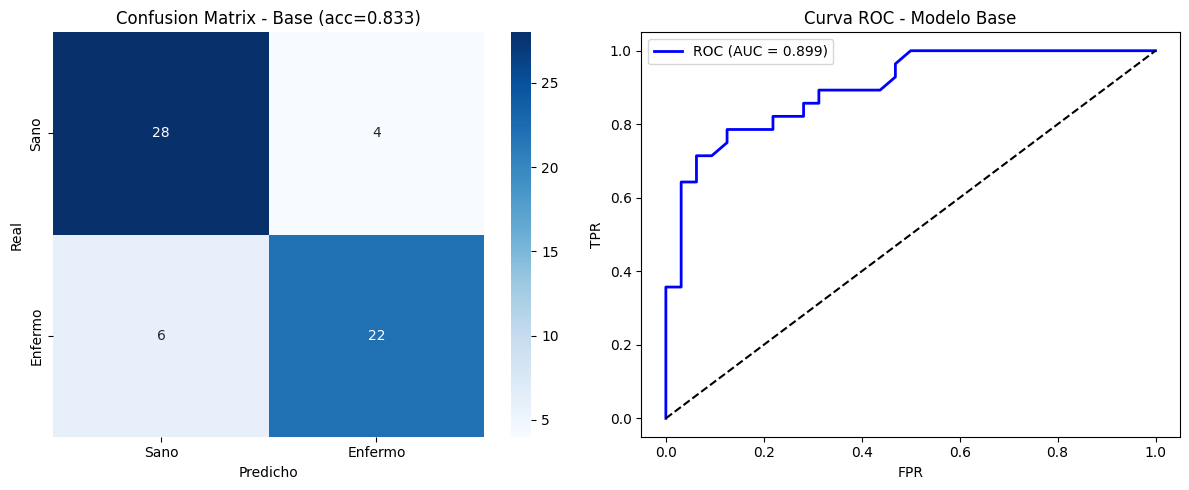

In [17]:
# Matriz de confusion y curva ROC
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_base)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Sano', 'Enfermo'], yticklabels=['Sano', 'Enfermo'])
axes[0].set_title(f'Confusion Matrix - Base (acc={acc_base:.3f})')
axes[0].set_ylabel('Real')
axes[0].set_xlabel('Predicho')

# Curva ROC
fpr_base, tpr_base, _ = roc_curve(y_test, y_proba_base)
auc_base = auc(fpr_base, tpr_base)
axes[1].plot(fpr_base, tpr_base, 'b-', lw=2, label=f'ROC (AUC = {auc_base:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--')
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')
axes[1].set_title('Curva ROC - Modelo Base')
axes[1].legend()

plt.tight_layout()
plt.show()

El modelo base con todas las variables nos da las metricas de referencia. En la matriz de confusion vemos cuantos pacientes clasifica correctamente como sanos y como enfermos, y tambien los errores (falsos positivos y falsos negativos). La curva ROC muestra la capacidad del modelo para distinguir entre las dos clases: cuanto mas arriba y a la izquierda este la curva, mejor. El AUC resume esto en un solo numero (1 = perfecto, 0.5 = aleatorio).

Estos numeros son nuestro punto de partida. Ahora vamos a analizar que features son realmente importantes y cuales podemos quitar.

---

<a name="3"></a>
# 3. Correlation Analysis

Como se explico en clase, el analisis de correlacion es el metodo mas sencillo para reduccion de dimensionalidad. Si dos features estan muy correlacionadas, una de ellas sobra porque da informacion redundante. Usamos el coeficiente de Pearson.

## 3.1 Matriz de correlacion y heatmap

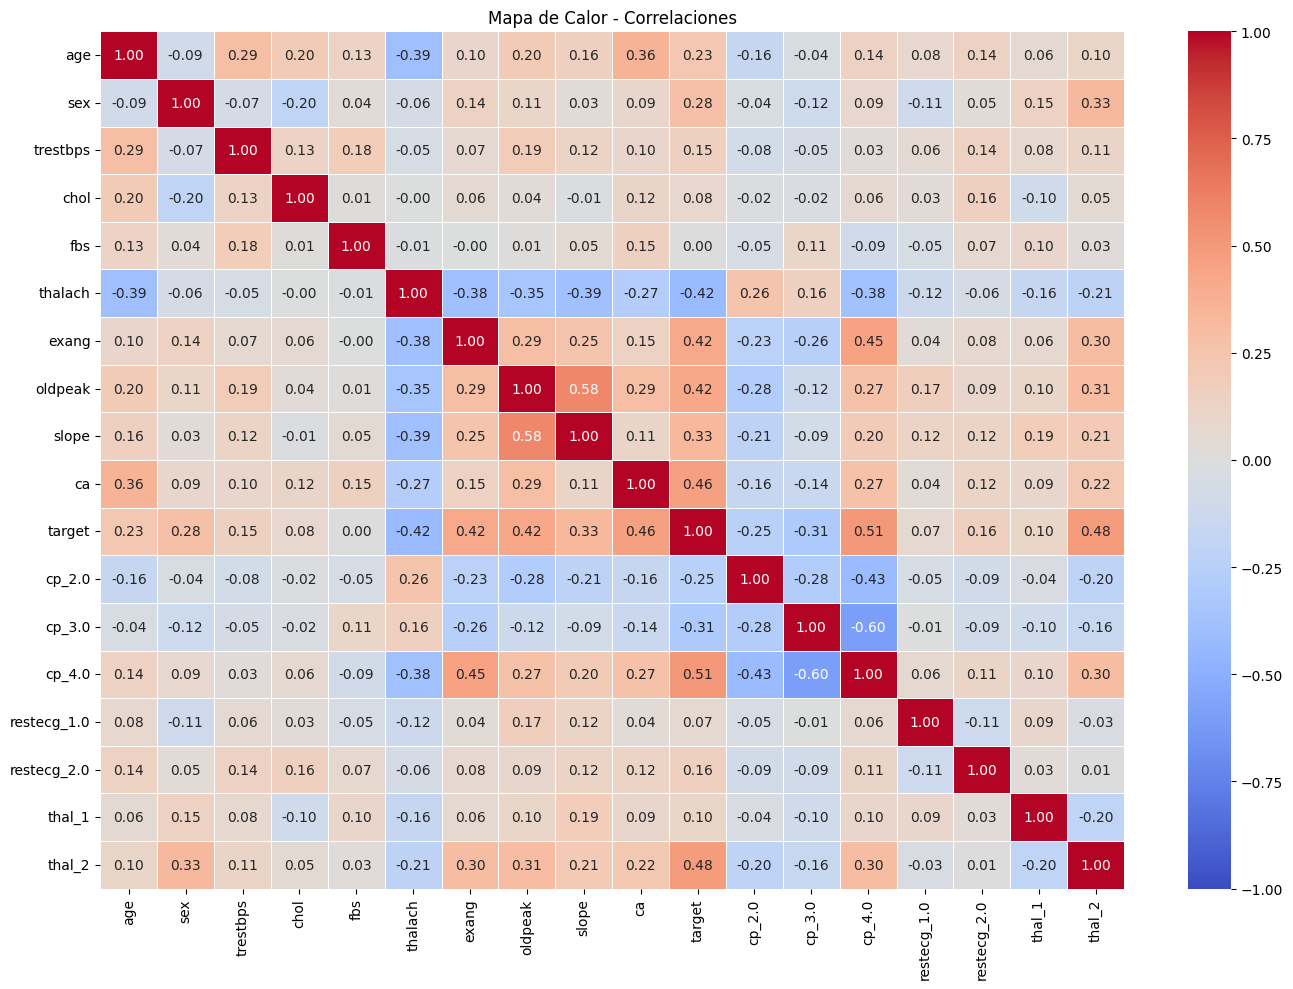

In [18]:
# Matriz de correlacion (como en el Colab de clase)
corr_matrix = dataset.corr()

# Heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, linewidths=0.5)
plt.title('Mapa de Calor - Correlaciones')
plt.tight_layout()
plt.show()

## 3.2 Correlacion con el target

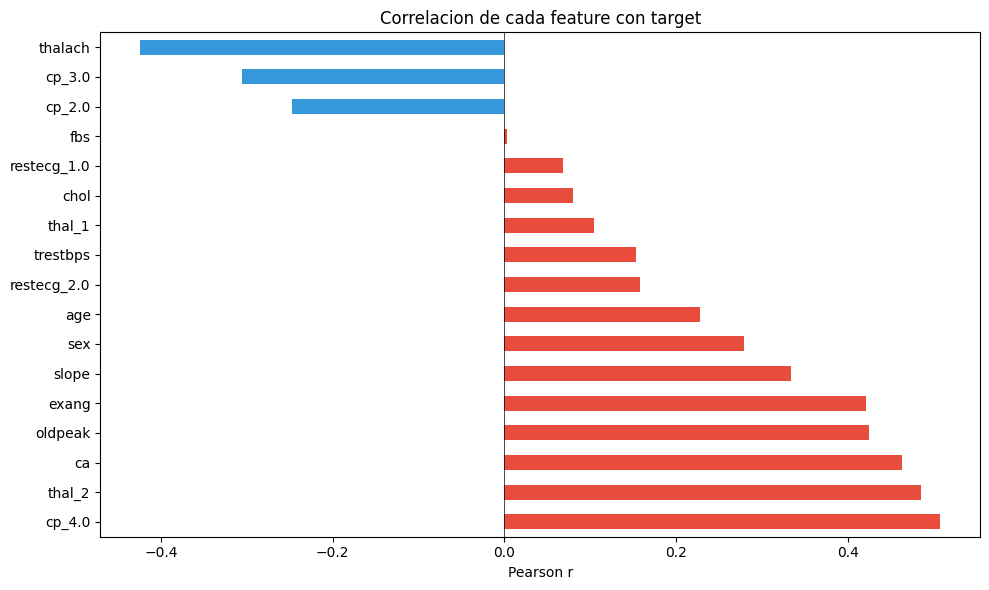

Correlaciones ordenadas por |r|:
cp_4.0         0.507
thal_2         0.485
ca             0.463
oldpeak        0.424
thalach        0.424
exang          0.421
slope          0.333
cp_3.0         0.305
sex            0.278
cp_2.0         0.248
age            0.227
restecg_2.0    0.157
trestbps       0.153
thal_1         0.105
chol           0.080
restecg_1.0    0.068
fbs            0.003
Name: target, dtype: float64


In [19]:
# Que features correlacionan mas con la enfermedad cardiaca?
corr_target = dataset.corr()['target'].drop('target').sort_values(ascending=False)

plt.figure(figsize=(10, 6))
colors = ['#e74c3c' if x > 0 else '#3498db' for x in corr_target]
corr_target.plot(kind='barh', color=colors)
plt.title('Correlacion de cada feature con target')
plt.xlabel('Pearson r')
plt.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

print('Correlaciones ordenadas por |r|:')
print(corr_target.abs().sort_values(ascending=False).round(3))

## 3.3 Pair plots

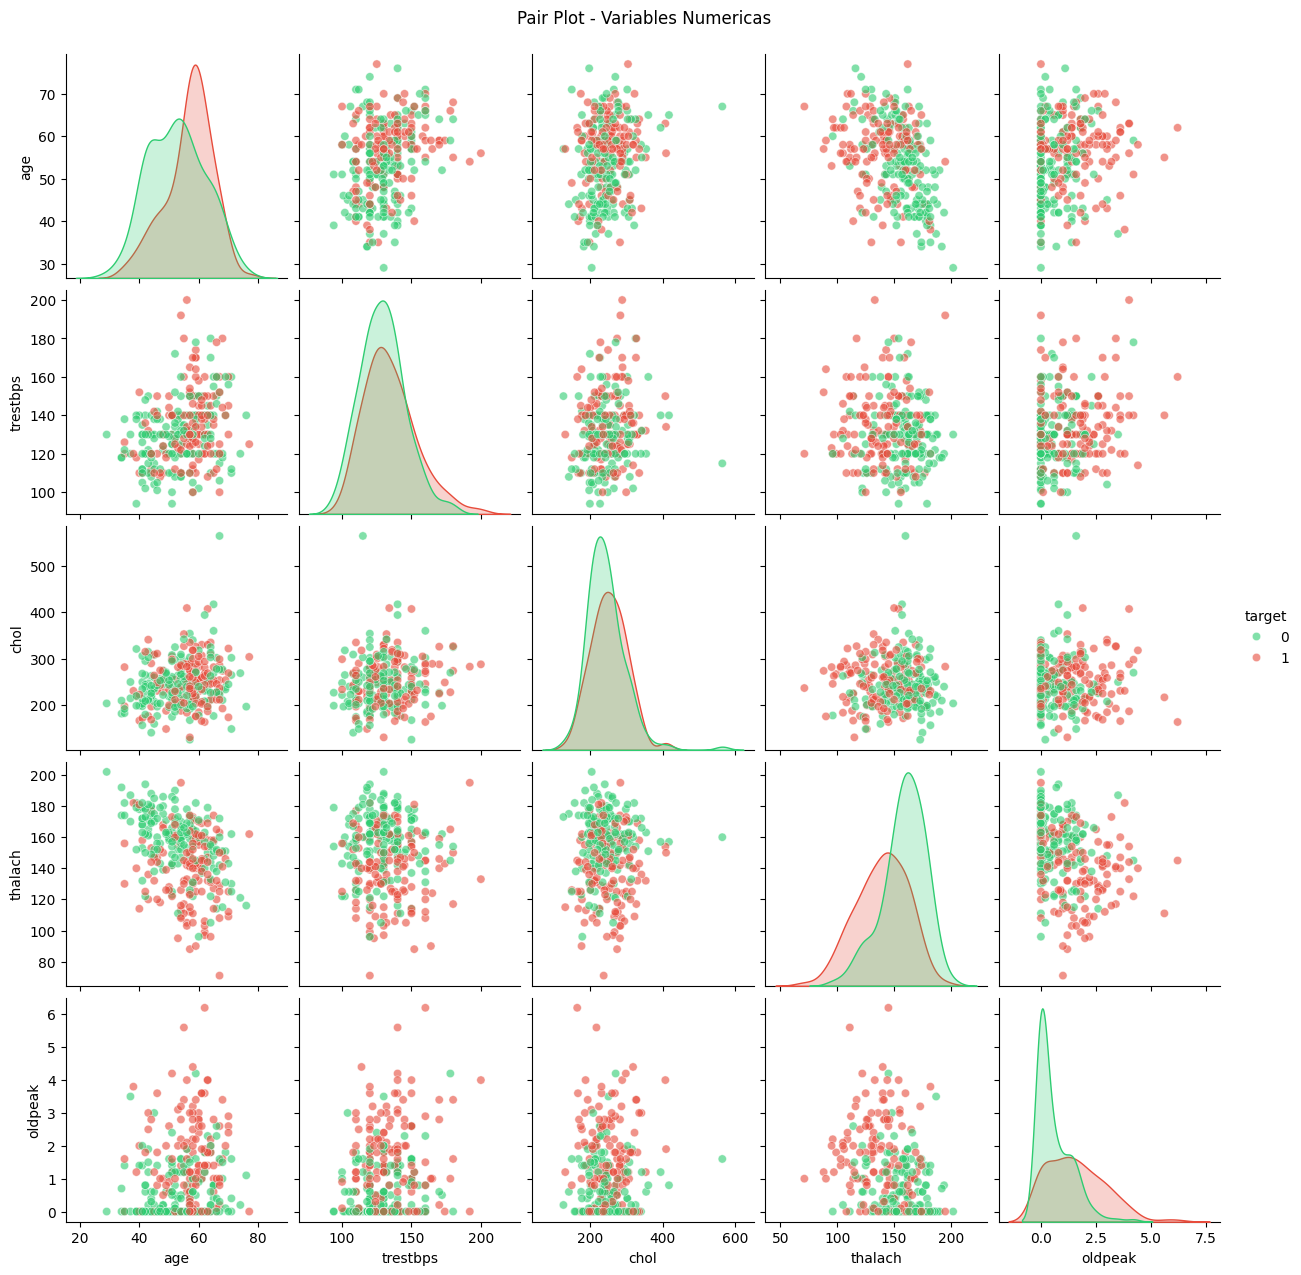

In [20]:
# Pair plot con las variables numericas principales
# No meto todas porque con 18 features seria ilegible
cols_pairplot = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'target']

sns.pairplot(dataset[cols_pairplot], hue='target',
             palette={0: '#2ecc71', 1: '#e74c3c'},
             diag_kind='kde', plot_kws={'alpha': 0.6})
plt.suptitle('Pair Plot - Variables Numericas', y=1.02)
plt.show()

## 3.4 Variables correlacionadas entre si

In [21]:
# Buscar pares con alta correlacion (excluyendo target)
corr_features = dataset.drop('target', axis=1).corr()
umbral = 0.5
pares = []

for i in range(len(corr_features.columns)):
    for j in range(i + 1, len(corr_features.columns)):
        r = corr_features.iloc[i, j]
        if abs(r) > umbral:
            pares.append((corr_features.columns[i], corr_features.columns[j], round(r, 3)))

if pares:
    pares.sort(key=lambda x: abs(x[2]), reverse=True)
    print(f'Pares con |r| > {umbral}:')
    for f1, f2, r in pares:
        print(f'  {f1} <-> {f2}: r = {r}')
else:
    print(f'No hay pares con |r| > {umbral}')
    # Bajo el umbral para ver algo
    umbral = 0.3
    for i in range(len(corr_features.columns)):
        for j in range(i + 1, len(corr_features.columns)):
            r = corr_features.iloc[i, j]
            if abs(r) > umbral:
                pares.append((corr_features.columns[i], corr_features.columns[j], round(r, 3)))
    pares.sort(key=lambda x: abs(x[2]), reverse=True)
    print(f'\nPares con |r| > {umbral}:')
    for f1, f2, r in pares:
        print(f'  {f1} <-> {f2}: r = {r}')

Pares con |r| > 0.5:
  cp_3.0 <-> cp_4.0: r = -0.596
  oldpeak <-> slope: r = 0.579


### Interpretacion del analisis de correlacion

Del analisis sacamos varias cosas:
- En el **heatmap** se ven las relaciones entre todas las variables. Las zonas con colores fuertes (rojo o azul) indican correlaciones altas, tanto positivas como negativas.
- En el **grafico de barras** vemos que features estan mas relacionadas con la enfermedad cardiaca. Las que tienen valores de |r| muy bajos (cercanos a 0) aportan poca informacion para predecir y son candidatas a eliminar.
- Si hay **pares de features muy correlacionadas entre si**, una de cada par es redundante porque aportan informacion parecida. De cada par nos quedamos con la que tenga mayor correlacion con el target.
- En el **pair plot** se puede ver visualmente como se distribuyen las dos clases para cada par de variables numericas. Donde las distribuciones se solapan mucho, esa variable separa peor las clases.

En las siguientes secciones comprobaremos si otros metodos (arbol de decision, ANOVA) confirman estos resultados.

---

<a name="4"></a>
# 4. Feature Importances

Como vimos en clase, los algoritmos basados en arboles calculan la importancia de cada feature segun cuanto contribuye a reducir la impureza (Gini o entropia). Es diferente a la correlacion porque puede captar relaciones no lineales.

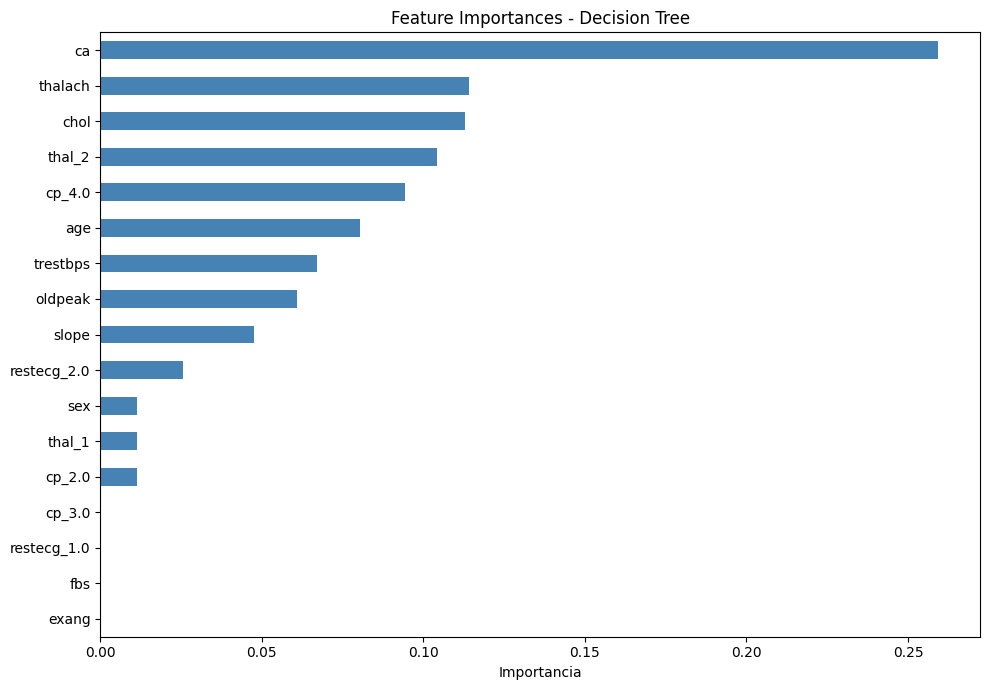

Ranking de importancia:
ca             0.2593
thalach        0.1141
chol           0.1128
thal_2         0.1043
cp_4.0         0.0944
age            0.0802
trestbps       0.0670
oldpeak        0.0607
slope          0.0477
restecg_2.0    0.0255
thal_1         0.0113
sex            0.0113
cp_2.0         0.0113
exang          0.0000
fbs            0.0000
cp_3.0         0.0000
restecg_1.0    0.0000
dtype: float64


In [22]:
# Creamos el modelo de arbol de decision
model = DecisionTreeClassifier(random_state=0)
model.fit(X_train_sc, y_train)

# Extraemos la importancia de cada variable
importance_dt = model.feature_importances_

# Grafico
importance_series = pd.Series(importance_dt, index=X_train.columns)
importance_sorted = importance_series.sort_values(ascending=True)

plt.figure(figsize=(10, 7))
importance_sorted.plot(kind='barh', color='steelblue')
plt.title('Feature Importances - Decision Tree')
plt.xlabel('Importancia')
plt.tight_layout()
plt.show()

print('Ranking de importancia:')
print(importance_series.sort_values(ascending=False).round(4))

### Comparativa con correlacion

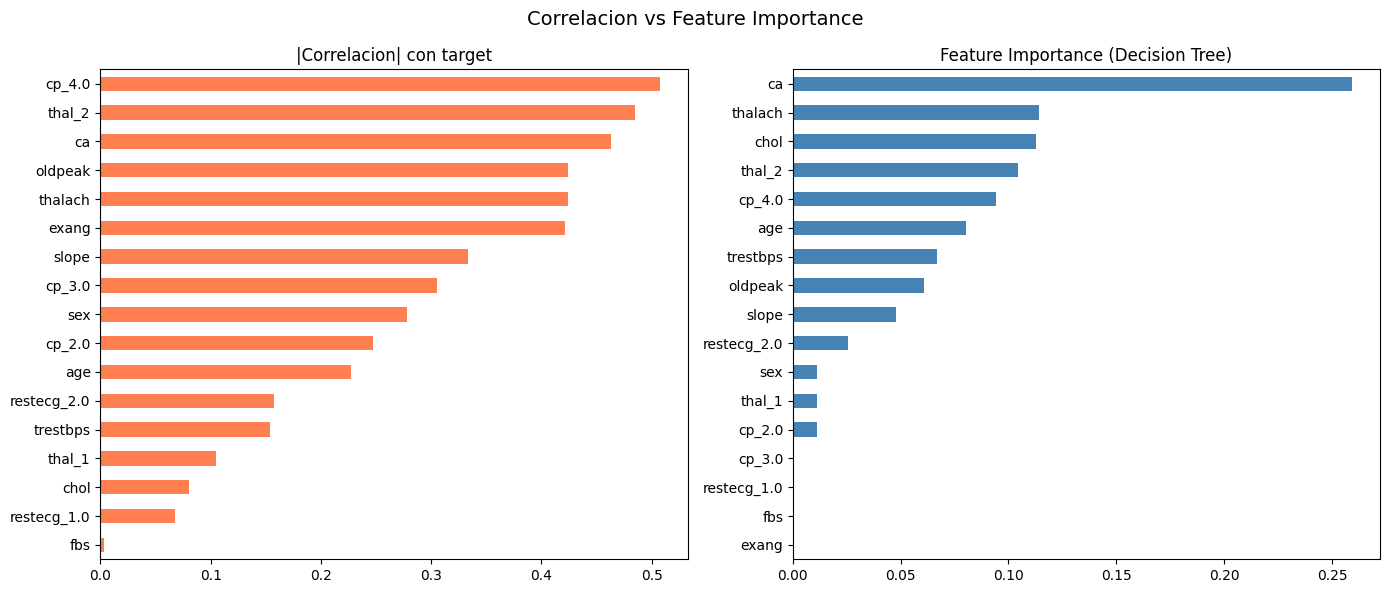

In [23]:
# Pongo los dos metodos lado a lado para comparar
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

corr_target.abs().sort_values().plot(kind='barh', ax=axes[0], color='coral')
axes[0].set_title('|Correlacion| con target')

importance_sorted.plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Feature Importance (Decision Tree)')

plt.suptitle('Correlacion vs Feature Importance', fontsize=14)
plt.tight_layout()
plt.show()

### Comparativa correlacion vs feature importance

Comparando los dos metodos lado a lado se ve que hay bastante coherencia: las features que la correlacion de Pearson marca como mas relacionadas con el target tambien tienden a aparecer como importantes en el arbol. Sin embargo no coinciden al 100%, y eso es normal. La correlacion solo mide relaciones **lineales**, mientras que el arbol puede captar relaciones mas complejas (no lineales e interacciones entre variables). Por eso es bueno usar varios metodos: lo que coincide en todos es mas fiable.

---

<a name="5"></a>
# 5. Univariate Selection (ANOVA)

Usamos `SelectKBest` con `f_classif` que es el test ANOVA F-test, igual que en el Colab de clase. Este test mide si la varianza de cada feature entre las clases es significativamente diferente. Un F-score alto = la feature discrimina bien entre clases. Un p-valor bajo = es estadisticamente significativo.

In [24]:
# SelectKBest con ANOVA (mismo patron que en clase)
test = SelectKBest(score_func=f_classif, k='all')  # k='all' para ver todos los scores
test.fit(X_train_sc, y_train)

# Interpretacion: cuanto MAS alto el F-score, mejor separa esa variable las clases
importance_kbest = test.scores_
p_values = test.pvalues_

# Tabla de resultados
anova_df = pd.DataFrame({
    'Feature': X_train.columns,
    'F-Score': importance_kbest,
    'p-valor': p_values
}).sort_values('F-Score', ascending=False)

print('Resultados ANOVA F-test:')
print(anova_df.to_string(index=False))

Resultados ANOVA F-test:
    Feature   F-Score      p-valor
     thal_2 70.961824 3.647260e-15
     cp_4.0 68.512230 9.502640e-15
    thalach 64.133280 5.373130e-14
         ca 63.034328 8.334692e-14
    oldpeak 60.310946 2.492543e-13
      exang 42.901574 3.592647e-10
      slope 37.483919 3.835260e-09
     cp_3.0 19.263137 1.721303e-05
     cp_2.0 17.804115 3.498640e-05
        sex 17.115437 4.901175e-05
        age 16.145073 7.901865e-05
restecg_2.0  7.100268 8.241238e-03
   trestbps  4.864759 2.837935e-02
       chol  2.365840 1.253625e-01
     thal_1  0.740916 3.902449e-01
restecg_1.0  0.519623 4.717191e-01
        fbs  0.009815 9.211675e-01


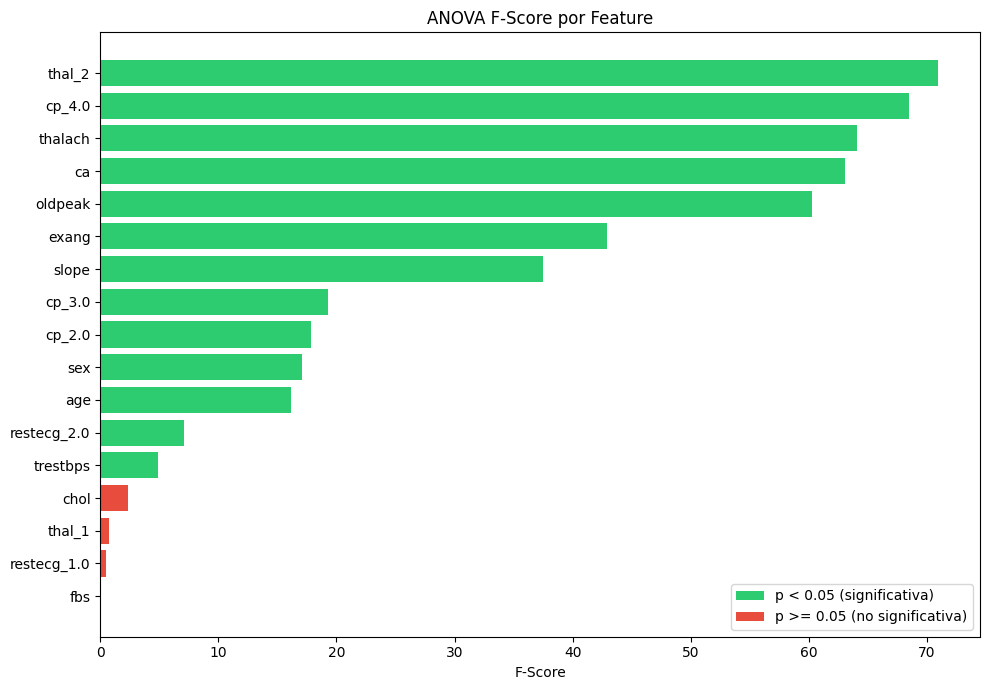

In [25]:
# Grafico de F-scores
from matplotlib.patches import Patch

plt.figure(figsize=(10, 7))
anova_plot = anova_df.sort_values('F-Score', ascending=True)
colores = ['#2ecc71' if p < 0.05 else '#e74c3c' for p in anova_plot['p-valor']]
plt.barh(anova_plot['Feature'], anova_plot['F-Score'], color=colores)
plt.title('ANOVA F-Score por Feature')
plt.xlabel('F-Score')

legend_elements = [Patch(facecolor='#2ecc71', label='p < 0.05 (significativa)'),
                   Patch(facecolor='#e74c3c', label='p >= 0.05 (no significativa)')]
plt.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.show()

### Interpretacion ANOVA

El test ANOVA complementa los analisis anteriores con un enfoque estadistico formal. Las features en **verde** (p-valor < 0.05) son estadisticamente significativas: la diferencia de medias entre pacientes sanos y enfermos es lo suficientemente grande como para no ser casualidad. Las que estan en **rojo** no superan el test y por tanto no resultan utiles para distinguir las clases.

Esto confirma lo que ya apuntaban la correlacion y las importancias del arbol: hay un grupo de features que claramente discriminan entre clases, y otro grupo que aporta poco.

---

<a name="6"></a>
# 6. Recursive Feature Elimination (RFE)

RFE funciona de forma iterativa: entrena un modelo, quita la feature menos importante, repite. Al final te dice cuales son las mejores.

Usamos LogisticRegression con `solver='lbfgs'` como en el ejemplo de clase.

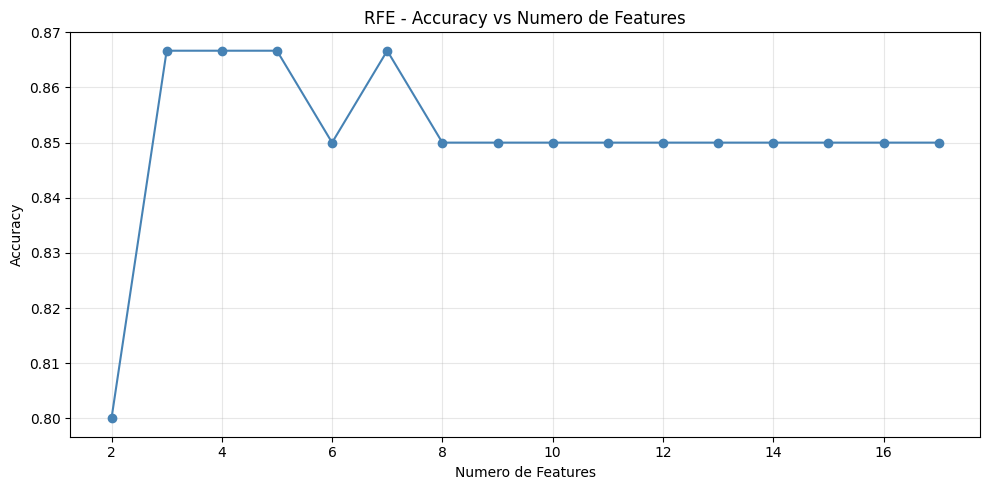

Mejor: 0.8667 con 3 features


In [26]:
# Probar con distinto numero de features para ver el optimo
resultados = []

for n in range(2, X_train_sc.shape[1] + 1):
    rfe = RFE(estimator=LogisticRegression(solver='lbfgs', max_iter=1000, random_state=0),
              n_features_to_select=n)
    rfe.fit(X_train_sc, y_train)
    score = rfe.score(X_test_sc, y_test)
    resultados.append({'n_features': n, 'accuracy': score})

df_rfe = pd.DataFrame(resultados)

plt.figure(figsize=(10, 5))
plt.plot(df_rfe['n_features'], df_rfe['accuracy'], 'o-', color='steelblue')
plt.xlabel('Numero de Features')
plt.ylabel('Accuracy')
plt.title('RFE - Accuracy vs Numero de Features')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

mejor = df_rfe.loc[df_rfe['accuracy'].idxmax()]
print(f'Mejor: {mejor["accuracy"]:.4f} con {int(mejor["n_features"])} features')

In [27]:
# RFE con el numero optimo (mismo patron que en clase)
n_optimo = int(mejor['n_features'])
rfe = RFE(estimator=LogisticRegression(solver='lbfgs', max_iter=1000, random_state=0),
          n_features_to_select=n_optimo)
rfe.fit(X_train_sc, y_train)

print(f'Num Features: {rfe.n_features_}')
print(f'Selected Features: {rfe.support_}')
print(f'Feature Ranking: {rfe.ranking_}')

# Features seleccionadas
features_rfe = X_train.columns[rfe.support_]
print(f'\nFeatures seleccionadas ({n_optimo}):')
print(list(features_rfe))

print(f'\nFeatures eliminadas:')
eliminadas = [f for f in X_train.columns if f not in features_rfe]
print(eliminadas)

Num Features: 3
Selected Features: [False False False False False False False False False  True False False
  True False False False  True]
Feature Ranking: [14  4 10  9 11  3  8  2  5  1 12  7  1 13  6 15  1]

Features seleccionadas (3):
['ca', 'cp_4.0', 'thal_2']

Features eliminadas:
['age', 'sex', 'trestbps', 'chol', 'fbs', 'thalach', 'exang', 'oldpeak', 'slope', 'cp_2.0', 'cp_3.0', 'restecg_1.0', 'restecg_2.0', 'thal_1']


### Interpretacion RFE

RFE prueba distintas combinaciones de features eliminando iterativamente las menos importantes. En la grafica se ve que a partir de cierto numero de features el accuracy se estabiliza o incluso puede bajar si anadimos mas (por el ruido extra). Las features que RFE selecciona coinciden en buena medida con las que los otros metodos (correlacion, arbol, ANOVA) marcaban como importantes, lo que refuerza la consistencia de los resultados.

---

<a name="7"></a>
# 7. Modelo con dataset reducido (eliminando variables correlacionadas)

En este punto utilizamos los resultados del analisis de correlacion (seccion 3) para **eliminar variables redundantes**. La idea es que si dos features estan muy correlacionadas entre si, aportan informacion parecida y podemos quedarnos solo con una. De cada par correlacionado, eliminamos la que tenga menor correlacion con el target (la menos util para predecir).

Hacemos esto para comprobar si, al quitar la informacion redundante, el modelo mantiene su rendimiento con menos variables.

In [28]:
# Usamos la matriz de correlacion de la seccion 3 para encontrar pares redundantes
corr_features = dataset.drop('target', axis=1).corr()
corr_with_target = dataset.corr()['target'].drop('target').abs()

# Buscamos pares con correlacion alta entre si
umbral_corr = 0.5
features_to_drop = set()

for i in range(len(corr_features.columns)):
    for j in range(i + 1, len(corr_features.columns)):
        if abs(corr_features.iloc[i, j]) > umbral_corr:
            col_i = corr_features.columns[i]
            col_j = corr_features.columns[j]
            # De cada par, quitamos la que menos correlaciona con target
            if corr_with_target[col_i] < corr_with_target[col_j]:
                features_to_drop.add(col_i)
                print(f'  {col_i} <-> {col_j} (r={corr_features.iloc[i,j]:.3f}) -> quito {col_i}')
            else:
                features_to_drop.add(col_j)
                print(f'  {col_i} <-> {col_j} (r={corr_features.iloc[i,j]:.3f}) -> quito {col_j}')

# Si no hay pares con 0.5, bajamos el umbral
if not features_to_drop:
    umbral_corr = 0.3
    print(f'No hay pares con |r| > 0.5, bajo el umbral a {umbral_corr}')
    for i in range(len(corr_features.columns)):
        for j in range(i + 1, len(corr_features.columns)):
            if abs(corr_features.iloc[i, j]) > umbral_corr:
                col_i = corr_features.columns[i]
                col_j = corr_features.columns[j]
                if corr_with_target[col_i] < corr_with_target[col_j]:
                    features_to_drop.add(col_i)
                    print(f'  {col_i} <-> {col_j} (r={corr_features.iloc[i,j]:.3f}) -> quito {col_i}')
                else:
                    features_to_drop.add(col_j)
                    print(f'  {col_i} <-> {col_j} (r={corr_features.iloc[i,j]:.3f}) -> quito {col_j}')

print(f'\nVariables eliminadas por correlacion: {features_to_drop}')
features_corr = [f for f in X_train.columns if f not in features_to_drop]
print(f'Variables restantes: {len(features_corr)} de {len(X_train.columns)}')

  oldpeak <-> slope (r=0.579) -> quito slope
  cp_3.0 <-> cp_4.0 (r=-0.596) -> quito cp_3.0

Variables eliminadas por correlacion: {'cp_3.0', 'slope'}
Variables restantes: 15 de 17


In [29]:
# Dataset reducido sin las variables correlacionadas
X_train_red = X_train_sc[features_corr]
X_test_red = X_test_sc[features_corr]
print(f'Shape reducido: {X_train_red.shape} (de {X_train_sc.shape[1]} a {X_train_red.shape[1]} features)')

# Entrenar Random Forest con el dataset sin variables correlacionadas
model_red = RandomForestClassifier(n_estimators=100, random_state=0)
model_red.fit(X_train_red, y_train)

y_pred_red = model_red.predict(X_test_red)
y_proba_red = model_red.predict_proba(X_test_red)[:, 1]

acc_red = accuracy_score(y_test, y_pred_red)
print(f'\nAccuracy base (todas): {acc_base:.4f}')
print(f'Accuracy sin correlacionadas ({len(features_corr)} feat): {acc_red:.4f}')
print()
print(confusion_matrix(y_test, y_pred_red))
print()
print(classification_report(y_test, y_pred_red))

Shape reducido: (237, 15) (de 17 a 15 features)

Accuracy base (todas): 0.8333
Accuracy sin correlacionadas (15 feat): 0.8500

[[29  3]
 [ 6 22]]

              precision    recall  f1-score   support

           0       0.83      0.91      0.87        32
           1       0.88      0.79      0.83        28

    accuracy                           0.85        60
   macro avg       0.85      0.85      0.85        60
weighted avg       0.85      0.85      0.85        60



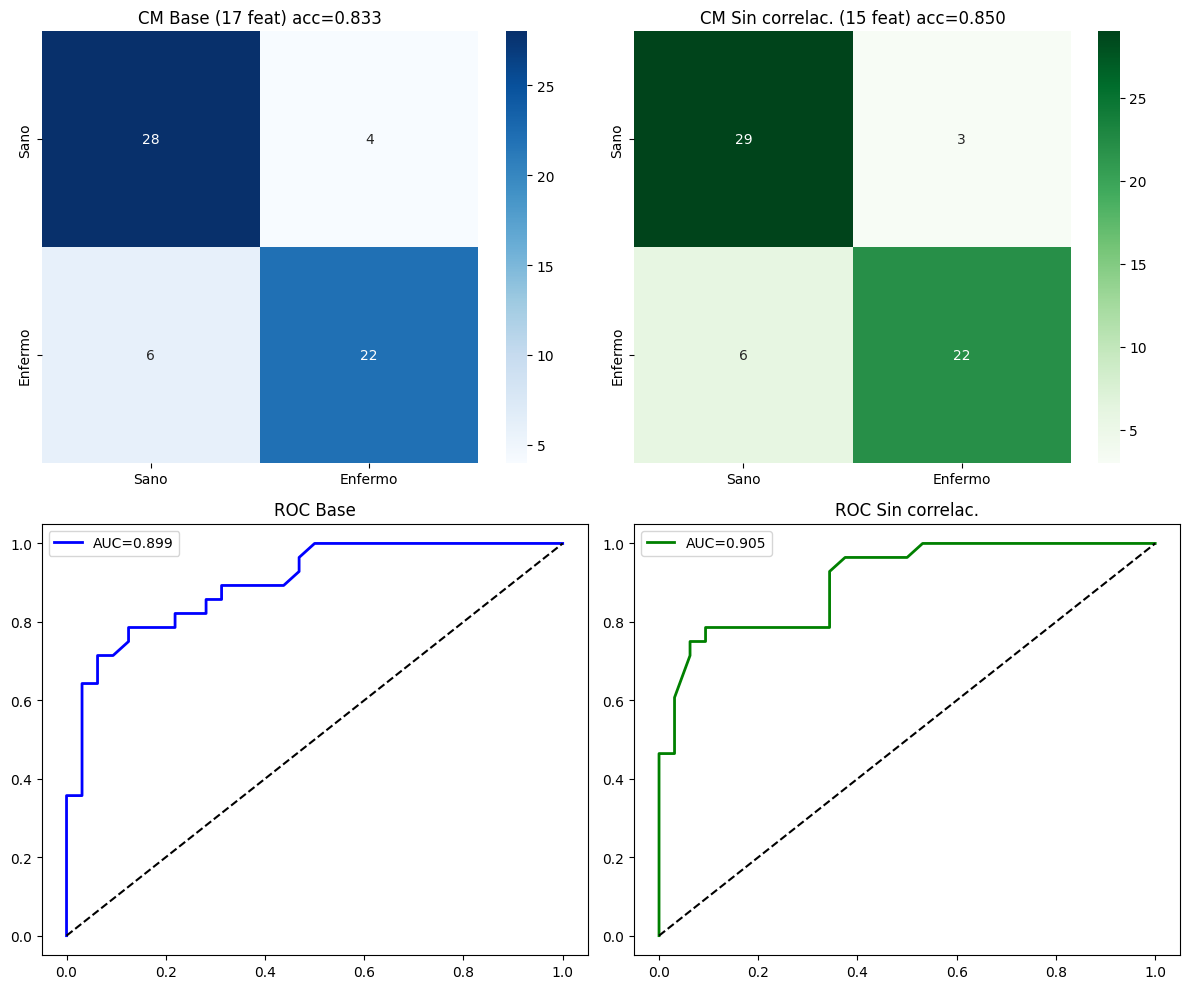

In [30]:
# Comparar matrices de confusion y curvas ROC
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# CM base
sns.heatmap(confusion_matrix(y_test, y_pred_base), annot=True, fmt='d',
            cmap='Blues', ax=axes[0, 0],
            xticklabels=['Sano', 'Enfermo'], yticklabels=['Sano', 'Enfermo'])
axes[0, 0].set_title(f'CM Base ({X_train_sc.shape[1]} feat) acc={acc_base:.3f}')

# CM reducido
sns.heatmap(confusion_matrix(y_test, y_pred_red), annot=True, fmt='d',
            cmap='Greens', ax=axes[0, 1],
            xticklabels=['Sano', 'Enfermo'], yticklabels=['Sano', 'Enfermo'])
axes[0, 1].set_title(f'CM Sin correlac. ({len(features_corr)} feat) acc={acc_red:.3f}')

# ROC base
axes[1, 0].plot(fpr_base, tpr_base, 'b-', lw=2, label=f'AUC={auc_base:.3f}')
axes[1, 0].plot([0, 1], [0, 1], 'k--')
axes[1, 0].set_title('ROC Base')
axes[1, 0].legend()

# ROC reducido
fpr_red, tpr_red, _ = roc_curve(y_test, y_proba_red)
auc_red = auc(fpr_red, tpr_red)
axes[1, 1].plot(fpr_red, tpr_red, 'g-', lw=2, label=f'AUC={auc_red:.3f}')
axes[1, 1].plot([0, 1], [0, 1], 'k--')
axes[1, 1].set_title('ROC Sin correlac.')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

### Interpretacion

Tras eliminar las variables que estaban correlacionadas entre si (quedandonos con la mas util de cada par), el modelo reducido obtiene un accuracy y AUC comparables al modelo base. Esto confirma lo que veiamos en el heatmap: esas variables aportaban informacion redundante. Al eliminarlas no solo simplificamos el modelo, sino que reducimos el riesgo de sobreajuste ya que hay menos variables que puedan meter ruido.

---

<a name="8"></a>
# 8. Reduccion de dimensionalidad con PCA

PCA es diferente a la seleccion de features: no elige features existentes sino que **crea nuevas variables** (componentes principales) que son combinaciones lineales de las originales. Las componentes se construyen de forma que la primera captura la mayor varianza posible, la segunda la mayor varianza restante, y asi sucesivamente.

Como en clase, primero ajustamos PCA sin fijar n_components para ver la varianza explicada, y luego elegimos cuantas componentes quedarnos.

## 8.1 Analisis de varianza explicada

In [31]:
# PCA sin fijar n_components (como en el ejemplo de clase)
# Asi calcula TODOS los componentes posibles
pca_full = PCA()
pca_full.fit(X_train_sc)

# explained_variance_ratio_ = % de varianza explicada por cada componente
# np.cumsum = suma acumulada
cum_expvar = np.cumsum(pca_full.explained_variance_ratio_)

print('Varianza explicada por componente:')
for i, (var, acum) in enumerate(zip(pca_full.explained_variance_ratio_, cum_expvar)):
    print(f'  PC{i+1}: {var:.4f} ({var*100:.1f}%)  |  Acumulada: {acum:.4f} ({acum*100:.1f}%)')

Varianza explicada por componente:
  PC1: 0.2060 (20.6%)  |  Acumulada: 0.2060 (20.6%)
  PC2: 0.0982 (9.8%)  |  Acumulada: 0.3042 (30.4%)
  PC3: 0.0846 (8.5%)  |  Acumulada: 0.3888 (38.9%)
  PC4: 0.0785 (7.8%)  |  Acumulada: 0.4672 (46.7%)
  PC5: 0.0742 (7.4%)  |  Acumulada: 0.5414 (54.1%)
  PC6: 0.0616 (6.2%)  |  Acumulada: 0.6030 (60.3%)
  PC7: 0.0594 (5.9%)  |  Acumulada: 0.6624 (66.2%)
  PC8: 0.0508 (5.1%)  |  Acumulada: 0.7132 (71.3%)
  PC9: 0.0474 (4.7%)  |  Acumulada: 0.7606 (76.1%)
  PC10: 0.0460 (4.6%)  |  Acumulada: 0.8066 (80.7%)
  PC11: 0.0435 (4.3%)  |  Acumulada: 0.8500 (85.0%)
  PC12: 0.0393 (3.9%)  |  Acumulada: 0.8894 (88.9%)
  PC13: 0.0323 (3.2%)  |  Acumulada: 0.9217 (92.2%)
  PC14: 0.0271 (2.7%)  |  Acumulada: 0.9488 (94.9%)
  PC15: 0.0239 (2.4%)  |  Acumulada: 0.9727 (97.3%)
  PC16: 0.0206 (2.1%)  |  Acumulada: 0.9932 (99.3%)
  PC17: 0.0068 (0.7%)  |  Acumulada: 1.0000 (100.0%)


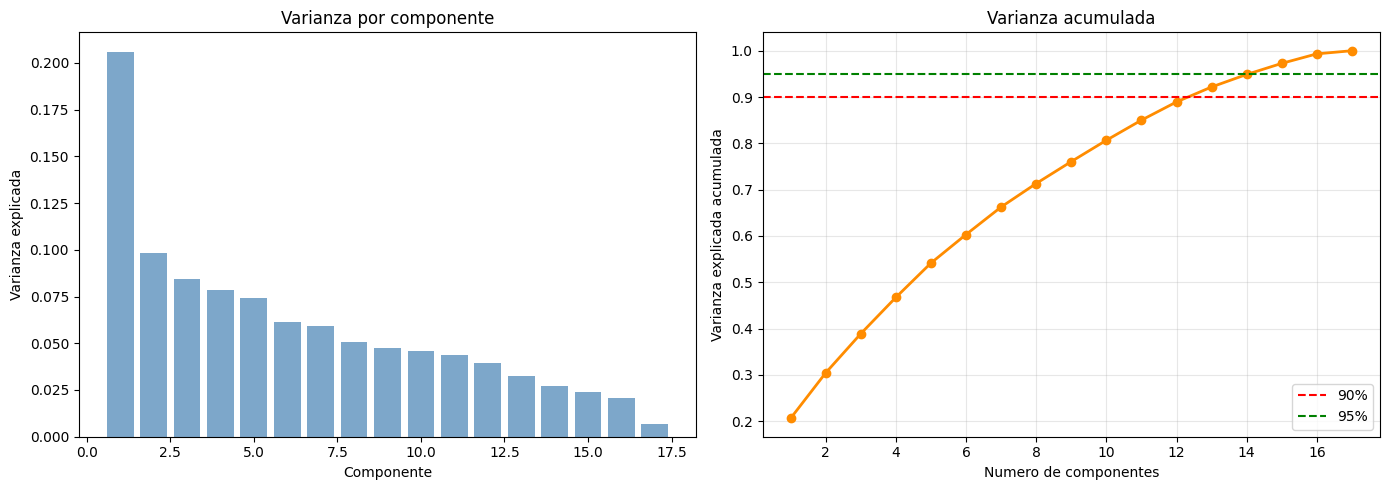

In [32]:
# Grafico de varianza acumulada (igual que en clase)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Varianza individual
axes[0].bar(range(1, len(pca_full.explained_variance_ratio_) + 1),
            pca_full.explained_variance_ratio_, color='steelblue', alpha=0.7)
axes[0].set_xlabel('Componente')
axes[0].set_ylabel('Varianza explicada')
axes[0].set_title('Varianza por componente')

# Varianza acumulada (este es el grafico clave de PCA)
axes[1].plot(range(1, len(cum_expvar) + 1), cum_expvar, 'o-', color='darkorange', lw=2)
axes[1].axhline(y=0.90, color='red', linestyle='--', label='90%')
axes[1].axhline(y=0.95, color='green', linestyle='--', label='95%')
axes[1].set_xlabel('Numero de componentes')
axes[1].set_ylabel('Varianza explicada acumulada')
axes[1].set_title('Varianza acumulada')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8.2 Elegir numero de componentes

In [33]:
# Cuantas componentes necesitamos para cada umbral?
for pct in [0.85, 0.90, 0.95]:
    n = np.argmax(cum_expvar >= pct) + 1
    print(f'{pct*100:.0f}% varianza -> {n} componentes')

# Me quedo con el 90% como buen compromiso
n_comp = np.argmax(cum_expvar >= 0.90) + 1
print(f'\nElegimos {n_comp} componentes (90% de la varianza)')

85% varianza -> 11 componentes
90% varianza -> 13 componentes
95% varianza -> 15 componentes

Elegimos 13 componentes (90% de la varianza)


## 8.3 Aplicar PCA

In [34]:
# Aplicar PCA con el numero seleccionado (mismo patron que en clase)
pca = PCA(n_components=n_comp)
X_train_pca = pca.fit_transform(X_train_sc)
X_test_pca = pca.transform(X_test_sc)

print(f'Antes: {X_train_sc.shape}')
print(f'Despues PCA: {X_train_pca.shape}')
print(f'Reduccion: de {X_train_sc.shape[1]} a {X_train_pca.shape[1]} componentes')
print(f'Varianza retenida: {sum(pca.explained_variance_ratio_)*100:.1f}%')

Antes: (237, 17)
Despues PCA: (237, 13)
Reduccion: de 17 a 13 componentes
Varianza retenida: 92.2%


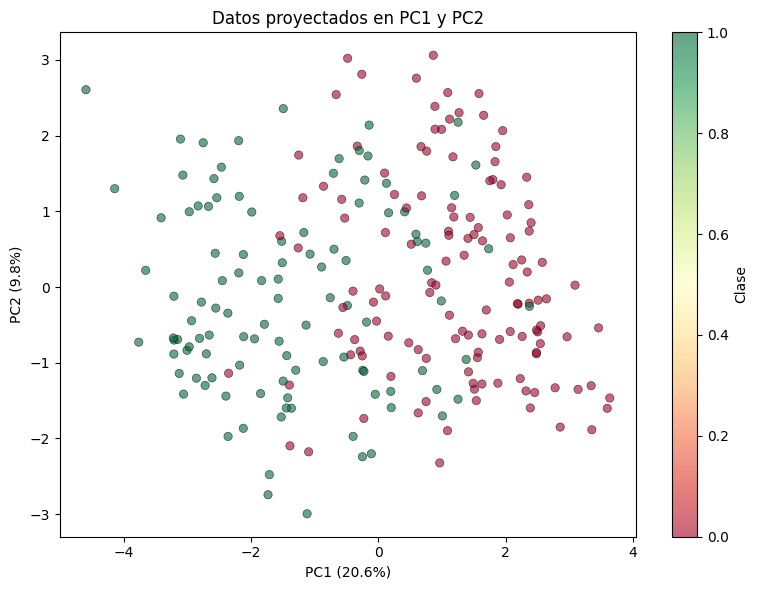

In [35]:
# Scatter de los datos en las 2 primeras componentes
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1],
                      c=y_train, cmap='RdYlGn', alpha=0.6, edgecolors='k', linewidth=0.5)
plt.colorbar(scatter, label='Clase')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('Datos proyectados en PC1 y PC2')
plt.tight_layout()
plt.show()

En la proyeccion 2D ya se intuye cierta separacion entre las clases, aunque no es perfecta (es un problema medico, no es facil). Con mas componentes la informacion es mayor.

---

<a name="9"></a>
# 9. Modelo de clasificacion con PCA

Entrenamos el mismo Random Forest pero con los datos transformados por PCA. Asi comparamos los tres enfoques: todas las features, seleccion de features y PCA.

In [36]:
# Random Forest con componentes PCA
model_pca = RandomForestClassifier(n_estimators=100, random_state=0)
model_pca.fit(X_train_pca, y_train)

y_pred_pca = model_pca.predict(X_test_pca)
y_proba_pca = model_pca.predict_proba(X_test_pca)[:, 1]

acc_pca = accuracy_score(y_test, y_pred_pca)
print(f'Accuracy PCA ({n_comp} comp): {acc_pca:.4f}')
print()
print(confusion_matrix(y_test, y_pred_pca))
print()
print(classification_report(y_test, y_pred_pca))

Accuracy PCA (13 comp): 0.8167

[[27  5]
 [ 6 22]]

              precision    recall  f1-score   support

           0       0.82      0.84      0.83        32
           1       0.81      0.79      0.80        28

    accuracy                           0.82        60
   macro avg       0.82      0.81      0.82        60
weighted avg       0.82      0.82      0.82        60



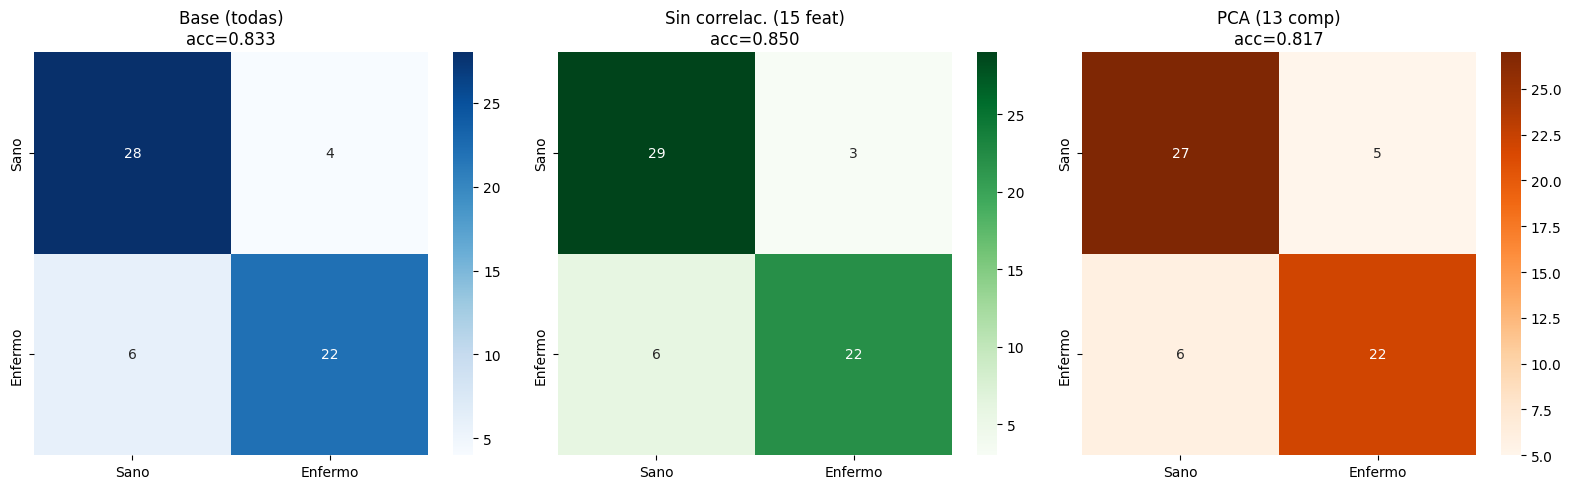

In [37]:
# Comparar los 3 modelos: matrices de confusion
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

modelos_info = [
    ('Base (todas)', y_pred_base, acc_base, 'Blues'),
    (f'Sin correlac. ({len(features_corr)} feat)', y_pred_red, acc_red, 'Greens'),
    (f'PCA ({n_comp} comp)', y_pred_pca, acc_pca, 'Oranges')
]

for i, (nombre, y_pred, acc, cmap) in enumerate(modelos_info):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=axes[i],
                xticklabels=['Sano', 'Enfermo'], yticklabels=['Sano', 'Enfermo'])
    axes[i].set_title(f'{nombre}\nacc={acc:.3f}')

plt.tight_layout()
plt.show()

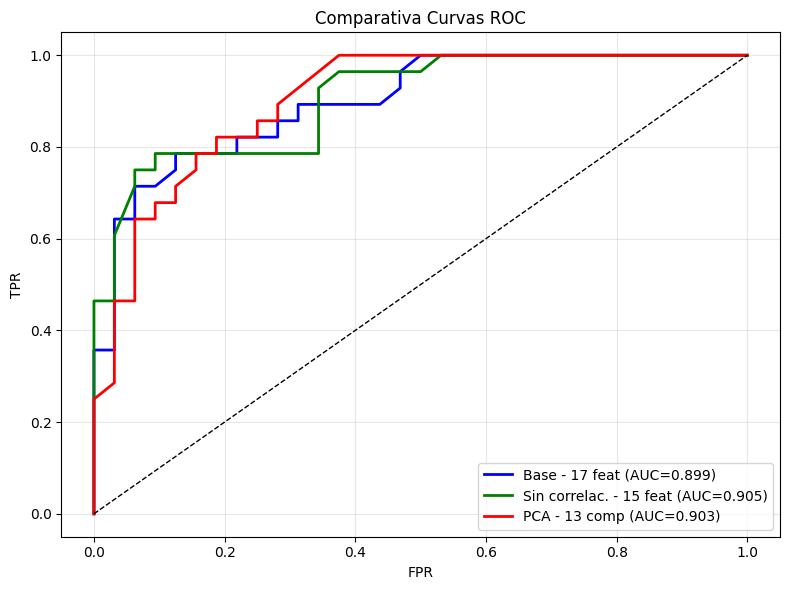

In [38]:
# Curvas ROC de los 3 modelos superpuestas
fpr_pca, tpr_pca, _ = roc_curve(y_test, y_proba_pca)
auc_pca = auc(fpr_pca, tpr_pca)

plt.figure(figsize=(8, 6))
plt.plot(fpr_base, tpr_base, 'b-', lw=2, label=f'Base - {X_train_sc.shape[1]} feat (AUC={auc_base:.3f})')
plt.plot(fpr_red, tpr_red, 'g-', lw=2, label=f'Sin correlac. - {len(features_corr)} feat (AUC={auc_red:.3f})')
plt.plot(fpr_pca, tpr_pca, 'r-', lw=2, label=f'PCA - {n_comp} comp (AUC={auc_pca:.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1)

plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('Comparativa Curvas ROC')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [39]:
# Tabla resumen
resumen = pd.DataFrame({
    'Modelo': [f'Base ({X_train_sc.shape[1]} feat)',
               f'Sin correlac. ({len(features_corr)} feat)',
               f'PCA ({n_comp} comp)'],
    'N variables': [X_train_sc.shape[1], len(features_corr), n_comp],
    'Accuracy': [acc_base, acc_red, acc_pca],
    'AUC': [auc_base, auc_red, auc_pca]
})

print('RESUMEN COMPARATIVO')
print('=' * 65)
print(resumen.to_string(index=False))
print('=' * 65)

RESUMEN COMPARATIVO
                 Modelo  N variables  Accuracy      AUC
         Base (17 feat)           17  0.833333 0.898996
Sin correlac. (15 feat)           15  0.850000 0.904576
          PCA (13 comp)           13  0.816667 0.903460


---

<a name="10"></a>
# 10. Conclusiones

En este trabajo he aplicado varias tecnicas de reduccion de dimensionalidad al dataset Heart Disease de Cleveland y he comparado como afectan al rendimiento de un clasificador Random Forest.

### Tecnicas aplicadas

**Correlacion (seccion 3):** Con la matriz de correlacion y el heatmap identifique que variables estaban relacionadas entre si y con el target. Es lo mas rapido de calcular pero solo detecta relaciones lineales.

**Feature Importances con Decision Tree (seccion 4):** El ranking de importancia del arbol fue bastante coherente con la correlacion, aunque no identico porque el arbol capta tambien relaciones no lineales.

**ANOVA F-test (seccion 5):** Confirmo estadisticamente cuales features son significativas (p < 0.05) para separar sanos de enfermos. Las no significativas coinciden con las que los otros metodos marcaban como poco utiles.

**RFE (seccion 6):** Encontro el numero optimo de features y cuales son, eliminando iterativamente las menos importantes. Es el metodo mas directo porque optimiza el accuracy del modelo.

**Eliminacion por correlacion (seccion 7):** Al quitar las variables correlacionadas entre si (quedandome con la mas util de cada par), el modelo mantuvo un rendimiento similar al baseline. Esto confirma que eran redundantes.

**PCA (secciones 8 y 9):** Crea nuevas componentes que son combinaciones lineales de las originales. Con la grafica de varianza acumulada elegi cuantas componentes retener (90%). La ventaja es que es automatico, la desventaja es que pierdes interpretabilidad (las componentes ya no tienen un significado clinico directo).

### Comparativa de resultados

Los tres modelos (base, reducido por correlacion y PCA) dieron resultados comparables en accuracy y AUC. Esto demuestra que no siempre hacen falta todas las variables para tener un buen modelo. Reducir dimensionalidad ayuda a tener modelos mas simples, mas rapidos y con menos riesgo de sobreajuste.

### Que metodo elegir

Depende del problema:
- Si necesitas **interpretabilidad** (por ejemplo un medico que quiere saber que factores influyen en la enfermedad): mejor seleccion de features (correlacion + RFE), porque mantienes las variables originales.
- Si solo necesitas **reducir dimensionalidad rapidamente** sin preocuparte de interpretar: PCA.
- En este dataset con 13 features la diferencia no es enorme, pero en datasets mas grandes (genomica, imagenes, NLP...) estas tecnicas son imprescindibles.

---

## Guardar dataset

In [40]:
# Guardar el dataset para la entrega
dataset.to_csv('heart_disease_processed.csv', index=False)
print('Dataset guardado como heart_disease_processed.csv')

Dataset guardado como heart_disease_processed.csv
